# Monthly Pattern Analysis and Curve Fitting

This notebook analyzes monthly patterns in water quality parameters (DRP, TA, EC) and fits:
1. **Sinusoidal curves** - to capture seasonal cyclical patterns
2. **Polynomial curves** - to capture non-linear trends

The fitted equations will be used to create `month_fitted` engineered features for each parameter.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Resolve project root robustly
cwd = os.getcwd()
cwd_base = os.path.basename(cwd)
if cwd_base == "preprocessing":
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, "..", ".."))
elif cwd_base == "Notebooks_Ours":
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    PROJECT_ROOT = os.path.abspath(cwd)

DATA_PATH = os.path.join(PROJECT_ROOT, "Datasets_Provided", "water_quality_training_dataset.csv")
OUTPUT_PKL = os.path.join(PROJECT_ROOT, "Notebooks_Ours", "preprocessing", "fitted_monthly_params.pkl")
OUTPUT_TXT = os.path.join(PROJECT_ROOT, "Notebooks_Ours", "preprocessing", "fitted_monthly_params.txt")

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Prepare Data

In [12]:
# Load water quality data with target variables
wq_data = pd.read_csv(DATA_PATH)

# Convert sample date to datetime (format: dd-mm-yyyy)
wq_data['Sample Date'] = pd.to_datetime(wq_data['Sample Date'], format='%d-%m-%Y')

# Extract month from sample date
wq_data['Month'] = wq_data['Sample Date'].dt.month

print(f"Dataset shape: {wq_data.shape}")
print(f"\nColumns: {list(wq_data.columns)}")
print(f"\nFirst few rows:")
print(wq_data.head())

# Check for missing values in target variables
print("\nMissing values:")
print(wq_data[['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'Month']].isnull().sum())

Dataset shape: (9319, 7)

Columns: ['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'Month']

First few rows:
    Latitude  Longitude Sample Date  Total Alkalinity  Electrical Conductance  \
0 -28.760833  17.730278  2011-01-02           128.912                   555.0   
1 -26.861111  28.884722  2011-01-03            74.720                   162.9   
2 -26.450000  28.085833  2011-01-03            89.254                   573.0   
3 -27.671111  27.236944  2011-01-03            82.000                   203.6   
4 -27.356667  27.286389  2011-01-03            56.100                   145.1   

   Dissolved Reactive Phosphorus  Month  
0                           10.0      1  
1                          163.0      1  
2                           80.0      1  
3                          101.0      1  
4                          151.0      1  

Missing values:
Total Alkalinity                 0
Electrical Conductance      

## 2. Calculate Monthly Averages

Monthly Statistics:
 Month    TA_mean    TA_std  TA_count    EC_mean     EC_std  EC_count  DRP_mean   DRP_std  DRP_count
     1 106.838447 68.379566       723 433.715934 331.861713       723 50.313278 54.572898        723
     2 100.244080 66.810321       741 396.556680 314.940428       741 45.757085 52.814665        741
     3 106.013235 65.340770       803 421.746779 311.313839       803 47.294521 52.191181        803
     4 110.603365 67.955278       774 457.973999 334.117064       774 45.711886 50.991841        774
     5 120.453346 72.646937       829 476.289891 318.206110       829 42.100724 49.058747        829
     6 123.254190 73.657426       820 510.192447 346.377540       820 36.763618 44.313573        820
     7 129.673497 77.654683       808 544.550450 354.190637       808 38.516089 47.737423        808
     8 129.875412 78.173060       810 532.741323 356.592393       810 38.738889 48.428040        810
     9 128.380529 78.898340       827 525.465545 352.092390       827 3

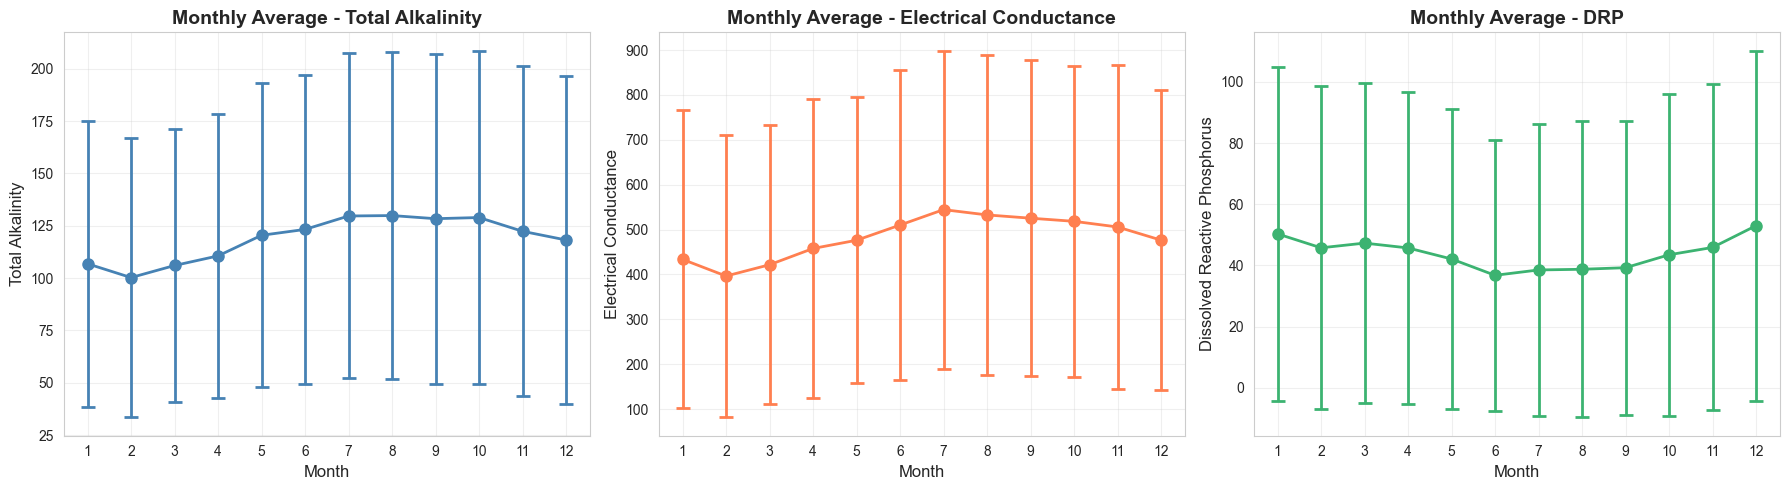

In [13]:
# Calculate average values for each month
monthly_stats = wq_data.groupby('Month').agg({
    'Total Alkalinity': ['mean', 'std', 'count'],
    'Electrical Conductance': ['mean', 'std', 'count'],
    'Dissolved Reactive Phosphorus': ['mean', 'std', 'count']
}).reset_index()

# Flatten column names
monthly_stats.columns = ['Month', 'TA_mean', 'TA_std', 'TA_count', 
                         'EC_mean', 'EC_std', 'EC_count',
                         'DRP_mean', 'DRP_std', 'DRP_count']

print("Monthly Statistics:")
print("="*80)
print(monthly_stats.to_string(index=False))

# Visualize monthly averages
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TA
axes[0].errorbar(monthly_stats['Month'], monthly_stats['TA_mean'], 
                 yerr=monthly_stats['TA_std'], marker='o', capsize=5, capthick=2, 
                 markersize=8, linewidth=2, color='steelblue')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Total Alkalinity', fontsize=12)
axes[0].set_title('Monthly Average - Total Alkalinity', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].grid(alpha=0.3)

# EC
axes[1].errorbar(monthly_stats['Month'], monthly_stats['EC_mean'], 
                 yerr=monthly_stats['EC_std'], marker='o', capsize=5, capthick=2,
                 markersize=8, linewidth=2, color='coral')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Electrical Conductance', fontsize=12)
axes[1].set_title('Monthly Average - Electrical Conductance', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].grid(alpha=0.3)

# DRP
axes[2].errorbar(monthly_stats['Month'], monthly_stats['DRP_mean'], 
                 yerr=monthly_stats['DRP_std'], marker='o', capsize=5, capthick=2,
                 markersize=8, linewidth=2, color='mediumseagreen')
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Dissolved Reactive Phosphorus', fontsize=12)
axes[2].set_title('Monthly Average - DRP', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(1, 13))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Define Curve Functions

In [14]:
# Sinusoidal function: y = A * sin(B * x + C) + D
def sinusoidal(x, A, B, C, D):
    """
    Sinusoidal function for seasonal patterns
    A: Amplitude
    B: Frequency (for monthly data, typically 2*pi/12)
    C: Phase shift
    D: Vertical offset (mean)
    """
    return A * np.sin(B * x + C) + D

# Polynomial function (degree 3): y = a*x^3 + b*x^2 + c*x + d
def polynomial_3(x, a, b, c, d):
    """
    3rd degree polynomial
    """
    return a * x**3 + b * x**2 + c * x + d

# Polynomial function (degree 2): y = a*x^2 + b*x + c
def polynomial_2(x, a, b, c):
    """
    2nd degree polynomial (quadratic)
    """
    return a * x**2 + b * x + c

print("Curve functions defined:")
print("1. Sinusoidal: y = A * sin(B * x + C) + D")
print("2. Polynomial (degree 3): y = a*x³ + b*x² + c*x + d")
print("3. Polynomial (degree 2): y = a*x² + b*x + c")

Curve functions defined:
1. Sinusoidal: y = A * sin(B * x + C) + D
2. Polynomial (degree 3): y = a*x³ + b*x² + c*x + d
3. Polynomial (degree 2): y = a*x² + b*x + c


## 4. Fit Curves to Data

In [15]:
def fit_curves(x, y, label):
    """
    Fit sinusoidal and polynomial curves to data
    """
    print(f"\n{'='*80}")
    print(f"Fitting curves for: {label}")
    print(f"{'='*80}")
    
    results = {}
    
    # 1. Fit Sinusoidal
    try:
        # Initial guesses for sinusoidal parameters
        A_guess = (np.max(y) - np.min(y)) / 2  # Amplitude
        D_guess = np.mean(y)  # Vertical offset
        B_guess = 2 * np.pi / 12  # One cycle per year
        C_guess = 0  # Phase shift
        
        popt_sin, pcov_sin = curve_fit(sinusoidal, x, y, 
                                       p0=[A_guess, B_guess, C_guess, D_guess],
                                       maxfev=10000)
        
        y_pred_sin = sinusoidal(x, *popt_sin)
        r2_sin = r2_score(y, y_pred_sin)
        rmse_sin = np.sqrt(mean_squared_error(y, y_pred_sin))
        
        results['sinusoidal'] = {
            'params': popt_sin,
            'r2': r2_sin,
            'rmse': rmse_sin,
            'y_pred': y_pred_sin,
            'equation': f"y = {popt_sin[0]:.4f} * sin({popt_sin[1]:.4f} * x + {popt_sin[2]:.4f}) + {popt_sin[3]:.4f}"
        }
        
        print(f"\nSinusoidal Fit:")
        print(f"  Equation: {results['sinusoidal']['equation']}")
        print(f"  R² Score: {r2_sin:.6f}")
        print(f"  RMSE: {rmse_sin:.4f}")
        print(f"  Parameters:")
        print(f"    A (Amplitude): {popt_sin[0]:.4f}")
        print(f"    B (Frequency): {popt_sin[1]:.4f}")
        print(f"    C (Phase): {popt_sin[2]:.4f}")
        print(f"    D (Offset): {popt_sin[3]:.4f}")
    except Exception as e:
        print(f"\nSinusoidal fit failed: {e}")
        results['sinusoidal'] = None
    
    # 2. Fit Polynomial (degree 3)
    try:
        popt_poly3, pcov_poly3 = curve_fit(polynomial_3, x, y, maxfev=10000)
        y_pred_poly3 = polynomial_3(x, *popt_poly3)
        r2_poly3 = r2_score(y, y_pred_poly3)
        rmse_poly3 = np.sqrt(mean_squared_error(y, y_pred_poly3))
        
        results['polynomial_3'] = {
            'params': popt_poly3,
            'r2': r2_poly3,
            'rmse': rmse_poly3,
            'y_pred': y_pred_poly3,
            'equation': f"y = {popt_poly3[0]:.6f}*x³ + {popt_poly3[1]:.6f}*x² + {popt_poly3[2]:.6f}*x + {popt_poly3[3]:.4f}"
        }
        
        print(f"\nPolynomial (degree 3) Fit:")
        print(f"  Equation: {results['polynomial_3']['equation']}")
        print(f"  R² Score: {r2_poly3:.6f}")
        print(f"  RMSE: {rmse_poly3:.4f}")
    except Exception as e:
        print(f"\nPolynomial (degree 3) fit failed: {e}")
        results['polynomial_3'] = None
    
    # 3. Fit Polynomial (degree 2)
    try:
        popt_poly2, pcov_poly2 = curve_fit(polynomial_2, x, y, maxfev=10000)
        y_pred_poly2 = polynomial_2(x, *popt_poly2)
        r2_poly2 = r2_score(y, y_pred_poly2)
        rmse_poly2 = np.sqrt(mean_squared_error(y, y_pred_poly2))
        
        results['polynomial_2'] = {
            'params': popt_poly2,
            'r2': r2_poly2,
            'rmse': rmse_poly2,
            'y_pred': y_pred_poly2,
            'equation': f"y = {popt_poly2[0]:.6f}*x² + {popt_poly2[1]:.6f}*x + {popt_poly2[2]:.4f}"
        }
        
        print(f"\nPolynomial (degree 2) Fit:")
        print(f"  Equation: {results['polynomial_2']['equation']}")
        print(f"  R² Score: {r2_poly2:.6f}")
        print(f"  RMSE: {rmse_poly2:.4f}")
    except Exception as e:
        print(f"\nPolynomial (degree 2) fit failed: {e}")
        results['polynomial_2'] = None
    
    return results

# Prepare data
months = monthly_stats['Month'].values

# Fit curves for each parameter
ta_fits = fit_curves(months, monthly_stats['TA_mean'].values, 'Total Alkalinity (TA)')
ec_fits = fit_curves(months, monthly_stats['EC_mean'].values, 'Electrical Conductance (EC)')
drp_fits = fit_curves(months, monthly_stats['DRP_mean'].values, 'Dissolved Reactive Phosphorus (DRP)')


Fitting curves for: Total Alkalinity (TA)

Sinusoidal Fit:
  Equation: y = -13.7422 * sin(0.4554 * x + 0.8642) + 117.4619
  R² Score: 0.963565
  RMSE: 1.9000
  Parameters:
    A (Amplitude): -13.7422
    B (Frequency): 0.4554
    C (Phase): 0.8642
    D (Offset): 117.4619

Polynomial (degree 3) Fit:
  Equation: y = -0.108917*x³ + 1.624983*x² + -2.879157*x + 104.6511
  R² Score: 0.938523
  RMSE: 2.4681

Polynomial (degree 2) Fit:
  Equation: y = -0.498894*x² + 8.611560*x + 89.7839
  R² Score: 0.822957
  RMSE: 4.1883

Fitting curves for: Electrical Conductance (EC)

Sinusoidal Fit:
  Equation: y = -62.4782 * sin(0.4683 * x + 0.7949) + 478.6538
  R² Score: 0.946747
  RMSE: 10.5231
  Parameters:
    A (Amplitude): -62.4782
    B (Frequency): 0.4683
    C (Phase): 0.7949
    D (Offset): 478.6538

Polynomial (degree 3) Fit:
  Equation: y = -0.510988*x³ + 7.634164*x² + -14.269716*x + 421.6536
  R² Score: 0.912422
  RMSE: 13.4948

Polynomial (degree 2) Fit:
  Equation: y = -2.330101*x² + 39.6

## 5. Visualize Fitted Curves

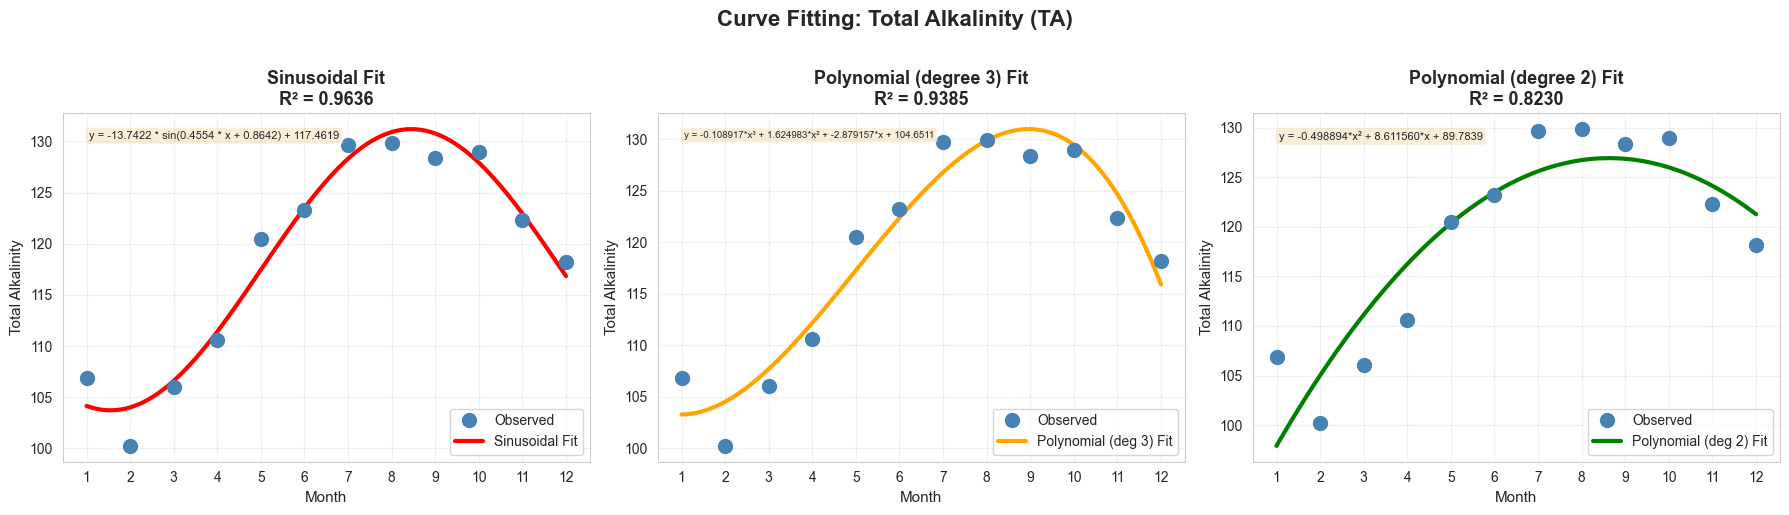

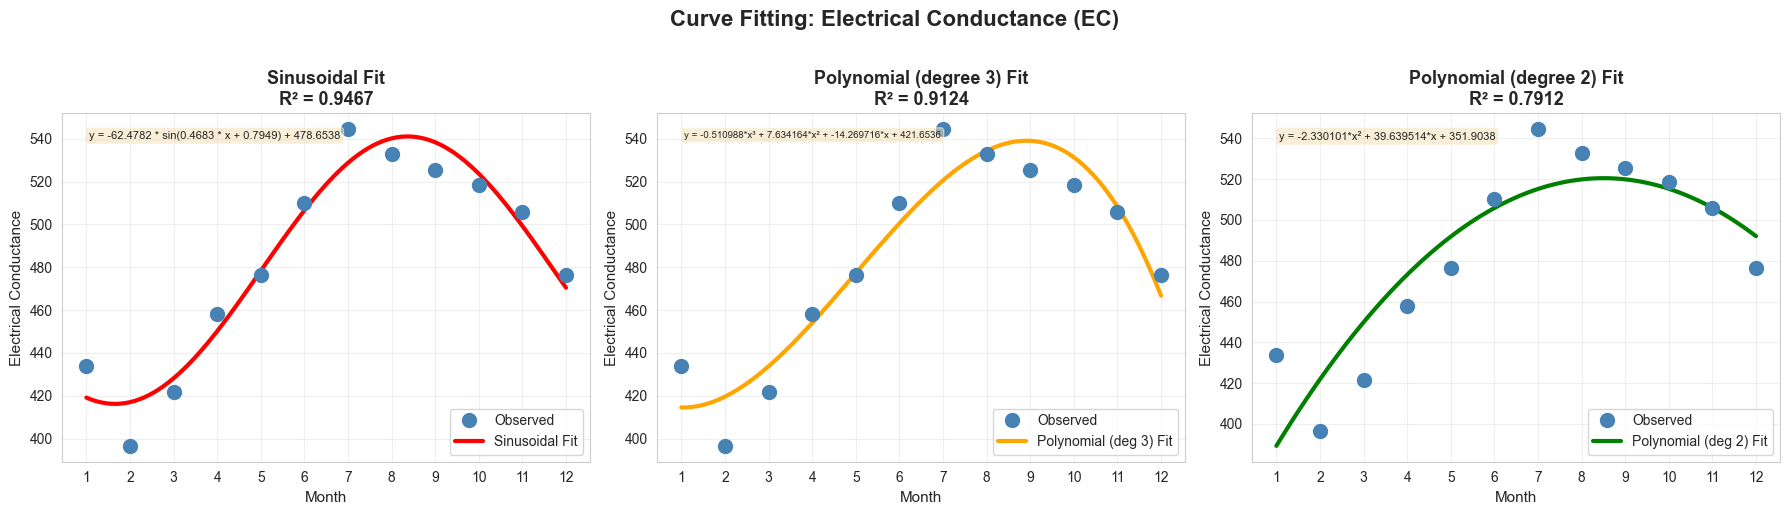

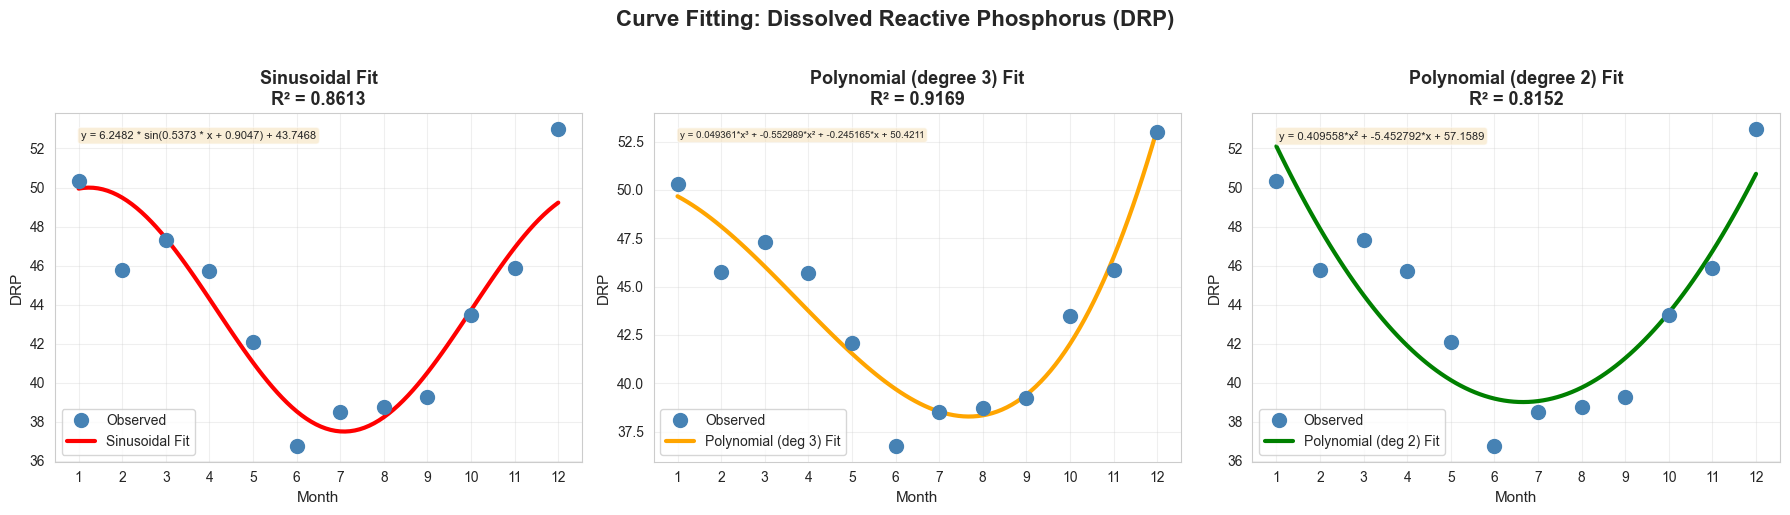

In [16]:
def plot_fits(x, y, fits, label, ylabel):
    """
    Plot original data and fitted curves
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Generate smooth curve for plotting
    x_smooth = np.linspace(1, 12, 100)
    
    # Plot 1: Sinusoidal
    if fits['sinusoidal']:
        y_smooth_sin = sinusoidal(x_smooth, *fits['sinusoidal']['params'])
        axes[0].plot(x, y, 'o', markersize=10, label='Observed', color='steelblue', zorder=3)
        axes[0].plot(x_smooth, y_smooth_sin, '-', linewidth=3, label='Sinusoidal Fit', color='red', zorder=2)
        axes[0].set_title(f"Sinusoidal Fit\nR² = {fits['sinusoidal']['r2']:.4f}", fontsize=13, fontweight='bold')
        axes[0].text(0.05, 0.95, fits['sinusoidal']['equation'], 
                    transform=axes[0].transAxes, fontsize=8, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        axes[0].plot(x, y, 'o', markersize=10, label='Observed', color='steelblue')
        axes[0].set_title('Sinusoidal Fit - Failed', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Month', fontsize=11)
    axes[0].set_ylabel(ylabel, fontsize=11)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_xticks(range(1, 13))
    
    # Plot 2: Polynomial (degree 3)
    if fits['polynomial_3']:
        y_smooth_poly3 = polynomial_3(x_smooth, *fits['polynomial_3']['params'])
        axes[1].plot(x, y, 'o', markersize=10, label='Observed', color='steelblue', zorder=3)
        axes[1].plot(x_smooth, y_smooth_poly3, '-', linewidth=3, label='Polynomial (deg 3) Fit', color='orange', zorder=2)
        axes[1].set_title(f"Polynomial (degree 3) Fit\nR² = {fits['polynomial_3']['r2']:.4f}", fontsize=13, fontweight='bold')
        axes[1].text(0.05, 0.95, fits['polynomial_3']['equation'], 
                    transform=axes[1].transAxes, fontsize=7, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        axes[1].plot(x, y, 'o', markersize=10, label='Observed', color='steelblue')
        axes[1].set_title('Polynomial (deg 3) Fit - Failed', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month', fontsize=11)
    axes[1].set_ylabel(ylabel, fontsize=11)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_xticks(range(1, 13))
    
    # Plot 3: Polynomial (degree 2)
    if fits['polynomial_2']:
        y_smooth_poly2 = polynomial_2(x_smooth, *fits['polynomial_2']['params'])
        axes[2].plot(x, y, 'o', markersize=10, label='Observed', color='steelblue', zorder=3)
        axes[2].plot(x_smooth, y_smooth_poly2, '-', linewidth=3, label='Polynomial (deg 2) Fit', color='green', zorder=2)
        axes[2].set_title(f"Polynomial (degree 2) Fit\nR² = {fits['polynomial_2']['r2']:.4f}", fontsize=13, fontweight='bold')
        axes[2].text(0.05, 0.95, fits['polynomial_2']['equation'], 
                    transform=axes[2].transAxes, fontsize=8, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        axes[2].plot(x, y, 'o', markersize=10, label='Observed', color='steelblue')
        axes[2].set_title('Polynomial (deg 2) Fit - Failed', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Month', fontsize=11)
    axes[2].set_ylabel(ylabel, fontsize=11)
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    axes[2].set_xticks(range(1, 13))
    
    fig.suptitle(f'Curve Fitting: {label}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Plot for each parameter
plot_fits(months, monthly_stats['TA_mean'].values, ta_fits, 
          'Total Alkalinity (TA)', 'Total Alkalinity')

plot_fits(months, monthly_stats['EC_mean'].values, ec_fits, 
          'Electrical Conductance (EC)', 'Electrical Conductance')

plot_fits(months, monthly_stats['DRP_mean'].values, drp_fits, 
          'Dissolved Reactive Phosphorus (DRP)', 'DRP')

## 6. Compare Model Performance


MODEL PERFORMANCE COMPARISON
Parameter        Model       R²      RMSE                                                 Equation
       TA   sinusoidal 0.963565  1.900030       y = -13.7422 * sin(0.4554 * x + 0.8642) + 117.4619
       TA polynomial_3 0.938523  2.468078  y = -0.108917*x³ + 1.624983*x² + -2.879157*x + 104.6511
       TA polynomial_2 0.822957  4.188321                  y = -0.498894*x² + 8.611560*x + 89.7839
       EC   sinusoidal 0.946747 10.523070       y = -62.4782 * sin(0.4683 * x + 0.7949) + 478.6538
       EC polynomial_3 0.912422 13.494782 y = -0.510988*x³ + 7.634164*x² + -14.269716*x + 421.6536
       EC polynomial_2 0.791216 20.836130                y = -2.330101*x² + 39.639514*x + 351.9038
      DRP   sinusoidal 0.861256  1.791242          y = 6.2482 * sin(0.5373 * x + 0.9047) + 43.7468
      DRP polynomial_3 0.916941  1.385930   y = 0.049361*x³ + -0.552989*x² + -0.245165*x + 50.4211
      DRP polynomial_2 0.815241  2.067046                  y = 0.409558*x² + -5

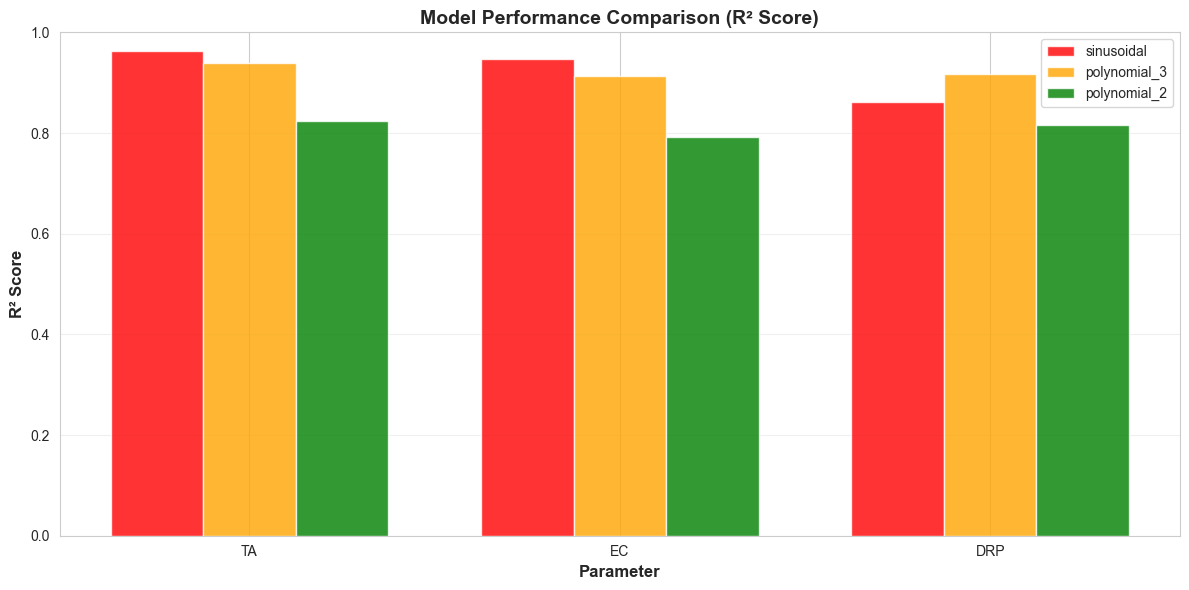

In [17]:
# Create comparison table
comparison_data = []

for param_name, fits in [('TA', ta_fits), ('EC', ec_fits), ('DRP', drp_fits)]:
    for model_name in ['sinusoidal', 'polynomial_3', 'polynomial_2']:
        if fits[model_name]:
            comparison_data.append({
                'Parameter': param_name,
                'Model': model_name,
                'R²': fits[model_name]['r2'],
                'RMSE': fits[model_name]['rmse'],
                'Equation': fits[model_name]['equation']
            })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*120)
print("MODEL PERFORMANCE COMPARISON")
print("="*120)
print(comparison_df.to_string(index=False))

# Visualize R² comparison
fig, ax = plt.subplots(figsize=(12, 6))

params = comparison_df['Parameter'].unique()
models = comparison_df['Model'].unique()
x = np.arange(len(params))
width = 0.25

colors = {'sinusoidal': 'red', 'polynomial_3': 'orange', 'polynomial_2': 'green'}

for i, model in enumerate(models):
    model_data = comparison_df[comparison_df['Model'] == model]
    r2_values = [model_data[model_data['Parameter'] == p]['R²'].values[0] if len(model_data[model_data['Parameter'] == p]) > 0 else 0 for p in params]
    ax.bar(x + i*width, r2_values, width, label=model, color=colors[model], alpha=0.8)

ax.set_xlabel('Parameter', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (R² Score)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(params)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 7. Select Best Models and Save Parameters

In [9]:
def select_best_model(fits):
    """
    Select the best model based on R² score
    """
    best_model = None
    best_r2 = -np.inf
    
    for model_name, fit_data in fits.items():
        if fit_data and fit_data['r2'] > best_r2:
            best_r2 = fit_data['r2']
            best_model = model_name
    
    return best_model

# Select best models
best_ta_model = select_best_model(ta_fits)
best_ec_model = select_best_model(ec_fits)
best_drp_model = select_best_model(drp_fits)

print("\n" + "="*80)
print("BEST MODELS SELECTED")
print("="*80)
print(f"\nTotal Alkalinity (TA):")
print(f"  Best Model: {best_ta_model}")
print(f"  R²: {ta_fits[best_ta_model]['r2']:.6f}")
print(f"  RMSE: {ta_fits[best_ta_model]['rmse']:.4f}")
print(f"  Equation: {ta_fits[best_ta_model]['equation']}")

print(f"\nElectrical Conductance (EC):")
print(f"  Best Model: {best_ec_model}")
print(f"  R²: {ec_fits[best_ec_model]['r2']:.6f}")
print(f"  RMSE: {ec_fits[best_ec_model]['rmse']:.4f}")
print(f"  Equation: {ec_fits[best_ec_model]['equation']}")

print(f"\nDissolved Reactive Phosphorus (DRP):")
print(f"  Best Model: {best_drp_model}")
print(f"  R²: {drp_fits[best_drp_model]['r2']:.6f}")
print(f"  RMSE: {drp_fits[best_drp_model]['rmse']:.4f}")
print(f"  Equation: {drp_fits[best_drp_model]['equation']}")

# Save parameters to dictionary for easy access
fitted_params = {
    'TA': {
        'model': best_ta_model,
        'params': ta_fits[best_ta_model]['params'],
        'equation': ta_fits[best_ta_model]['equation'],
        'r2': ta_fits[best_ta_model]['r2']
    },
    'EC': {
        'model': best_ec_model,
        'params': ec_fits[best_ec_model]['params'],
        'equation': ec_fits[best_ec_model]['equation'],
        'r2': ec_fits[best_ec_model]['r2']
    },
    'DRP': {
        'model': best_drp_model,
        'params': drp_fits[best_drp_model]['params'],
        'equation': drp_fits[best_drp_model]['equation'],
        'r2': drp_fits[best_drp_model]['r2']
    }
}

print("\n✓ Parameters saved for feature engineering!")


BEST MODELS SELECTED

Total Alkalinity (TA):
  Best Model: sinusoidal
  R²: 0.963565
  RMSE: 1.9000
  Equation: y = -13.7422 * sin(0.4554 * x + 0.8642) + 117.4619

Electrical Conductance (EC):
  Best Model: sinusoidal
  R²: 0.946747
  RMSE: 10.5231
  Equation: y = -62.4782 * sin(0.4683 * x + 0.7949) + 478.6538

Dissolved Reactive Phosphorus (DRP):
  Best Model: polynomial_3
  R²: 0.916941
  RMSE: 1.3859
  Equation: y = 0.049361*x³ + -0.552989*x² + -0.245165*x + 50.4211

✓ Parameters saved for feature engineering!


## 8. Export Fitted Parameters

In [18]:
import pickle

# Save fitted parameters to pickle file
output_file = OUTPUT_PKL
with open(output_file, 'wb') as f:
    pickle.dump(fitted_params, f)

print(f"✓ Fitted parameters saved to: {output_file}")

# Also save as a readable text file
output_txt = OUTPUT_TXT
with open(output_txt, 'w') as f:
    f.write("="*80 + "\n")
    f.write("FITTED MONTHLY CURVE PARAMETERS\n")
    f.write("="*80 + "\n\n")
    
    for param_name, data in fitted_params.items():
        f.write(f"{param_name}:\n")
        f.write(f"  Model: {data['model']}\n")
        f.write(f"  Equation: {data['equation']}\n")
        f.write(f"  R²: {data['r2']:.6f}\n")
        f.write(f"  Parameters: {data['params']}\n")
        f.write("\n")

print(f"✓ Readable parameters saved to: {output_txt}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nNext steps:")
print("1. Use fitted_monthly_params.pkl to create 'month_fitted' feature")
print("2. Apply the appropriate equation based on the target variable (TA, EC, or DRP)")
print("3. The month_fitted feature will capture seasonal patterns in water quality")

✓ Fitted parameters saved to: /Users/aaravsonthalia/Projects/Water-Quality-Prediction/Notebooks_Ours/preprocessing/fitted_monthly_params.pkl
✓ Readable parameters saved to: /Users/aaravsonthalia/Projects/Water-Quality-Prediction/Notebooks_Ours/preprocessing/fitted_monthly_params.txt

ANALYSIS COMPLETE

Next steps:
1. Use fitted_monthly_params.pkl to create 'month_fitted' feature
2. Apply the appropriate equation based on the target variable (TA, EC, or DRP)
3. The month_fitted feature will capture seasonal patterns in water quality
